In [ ]:
!pip install matplotlib
!pip install transformers
!pip install spacy
!python -m spacy download fr_core_news_sm

In [ ]:
import pandas as pd
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from transformers import AutoTokenizer
import spacy

import os

/Users/macbook/opt/anaconda3/envs/mlfinance/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [4]:
df = pd.read_csv("data/df_final.csv")
df = df.drop(columns=["Unnamed: 0"])

In [5]:
print("Aperçu du dataframe :")
display(df.head())

print("Shape :", df.shape)
print("\nValeurs manquantes :")
print(df.isna().sum())

Aperçu du dataframe :


,texte,orientation
0,REPUBLIQUE FRANCAISE - LIBERTE - EGALITE - FRA...,gauche
1,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇA...,droite
2,REPUBLIQUE FRANCAISE - LIBERTE - EGALITE - FRA...,gauche
3,RÉPUBLIQUE FRANÇAISE - Liberté - Egalité - Fra...,gauche
4,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,gauche


Shape : (6201, 2)

Valeurs manquantes :
texte          0
orientation    0
dtype: int64


In [ ]:
# VARIABLES DE LONGUEUR

# Charger le tokenizer du modèle
nlp = spacy.load("fr_core_news_sm")

def clean_text_basic(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["texte_clean"] = df["texte"].apply(clean_text_basic)

# Longueur en caractères
df["nb_caracteres"] = df["texte_clean"].apply(len)

# Longueur en mots
df["nb_mots"] = df["texte_clean"].apply(lambda x: len(x.split()))

# Longueur en phrases
df["nb_phrases"] = df["texte_clean"].apply(
    lambda x: len([s for s in re.split(r"[.!?]+", x) if s.strip() != ""])
)

# Longueur en tokens
df["nb_tokens"] = df["texte_clean"].apply(lambda x: len(nlp(x)))

print("\nStatistiques globales sur les longueurs :")

stats = df[["nb_caracteres", "nb_mots", "nb_phrases", "nb_tokens"]].describe()
stats = stats.round(0).astype(int)

display(stats)


Statistiques globales sur les longueurs :


,nb_caracteres,nb_mots,nb_phrases,nb_tokens
count,6201,6201,6201,6201
mean,4372,695,38,813
std,2290,365,23,431
min,302,43,1,44
25%,2760,436,22,507
50%,3799,600,32,701
75%,5504,880,48,1026
max,20004,3158,232,3622


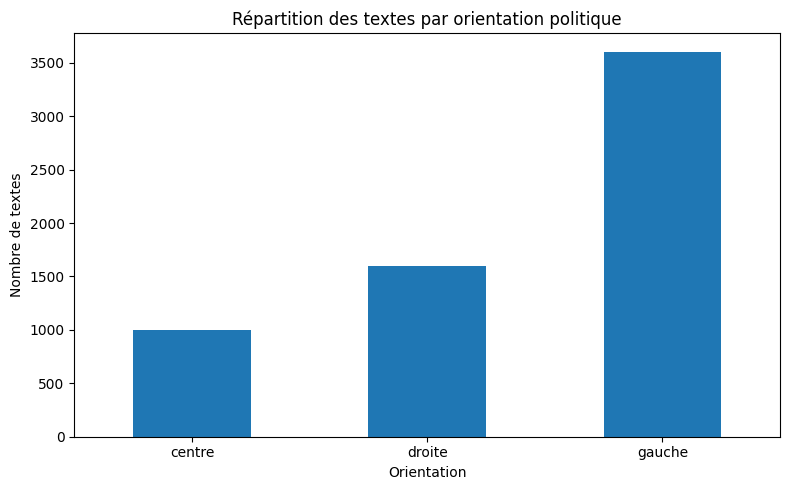


Répartition des classes :


,effectif
orientation,
centre,999
droite,1601
gauche,3601



Proportions des classes :


,%
orientation,
gauche,58.07
droite,25.82
centre,16.11


In [ ]:
# RÉPARTITION DES CLASSES

class_counts = df["orientation"].value_counts().sort_index()
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("Répartition des textes par orientation politique")
plt.xlabel("Orientation")
plt.ylabel("Nombre de textes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/repartition_classes.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nRépartition des classes :")
display(class_counts.to_frame(name="effectif"))

print("\nProportions des classes :")
display((df["orientation"].value_counts(normalize=True) * 100).round(2).to_frame(name="%"))

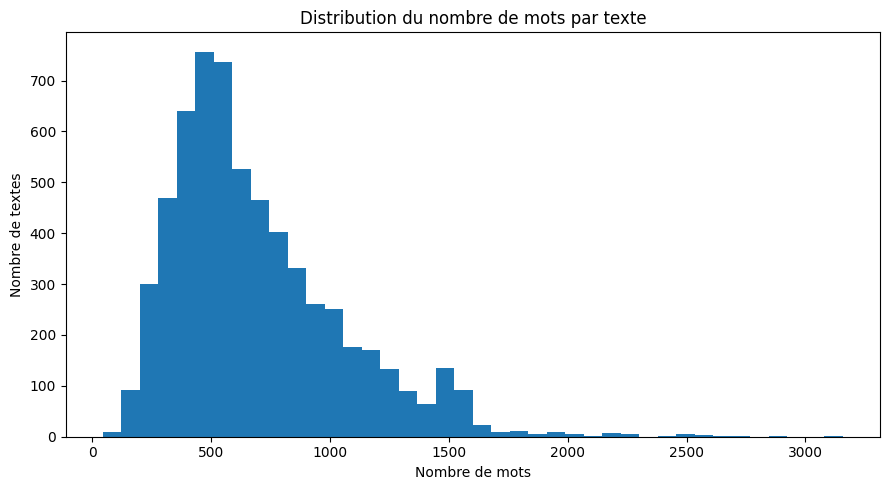

In [ ]:
# HISTOGRAMME DES LONGUEURS DE TEXTES (Nombre de mots)

plt.figure(figsize=(9, 5))
plt.hist(df["nb_mots"], bins=40)
plt.title("Distribution du nombre de mots par texte")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de textes")
plt.tight_layout()
plt.savefig("figures/distribution_nb_mots.png", dpi=300, bbox_inches="tight")
plt.show()

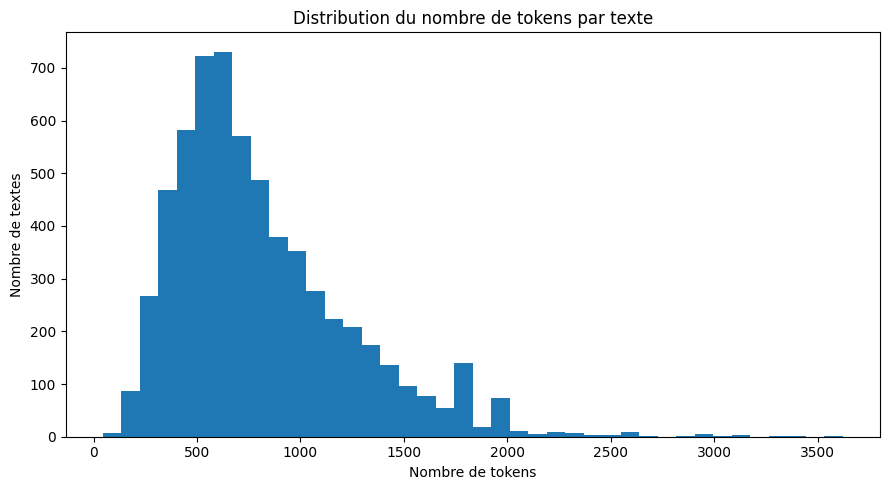

In [ ]:
# HISTOGRAMME DES LONGUEURS DE TEXTES (Nombre de tokens)

plt.figure(figsize=(9, 5))
plt.hist(df["nb_tokens"], bins=40)
plt.title("Distribution du nombre de tokens par texte")
plt.xlabel("Nombre de tokens")
plt.ylabel("Nombre de textes")
plt.tight_layout()
plt.savefig("figures/distribution_nb_tokens.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 800x500 with 0 Axes>

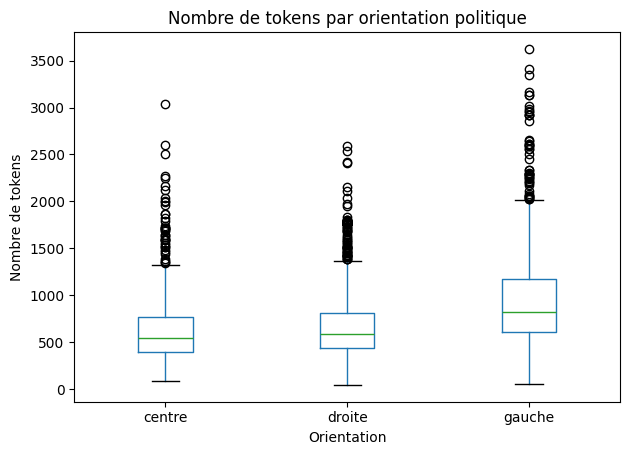

In [ ]:
# BOXPLOT DES LONGUEURS PAR CLASSE (Nombre de tokens)

plt.figure(figsize=(8, 5))
df.boxplot(column="nb_tokens", by="orientation", grid=False)
plt.title("Nombre de tokens par orientation politique")
plt.suptitle("")
plt.xlabel("Orientation")
plt.ylabel("Nombre de tokens")
plt.tight_layout()
plt.savefig("figures/boxplot_tokens_orientation.png", dpi=300, bbox_inches="tight")
plt.show()

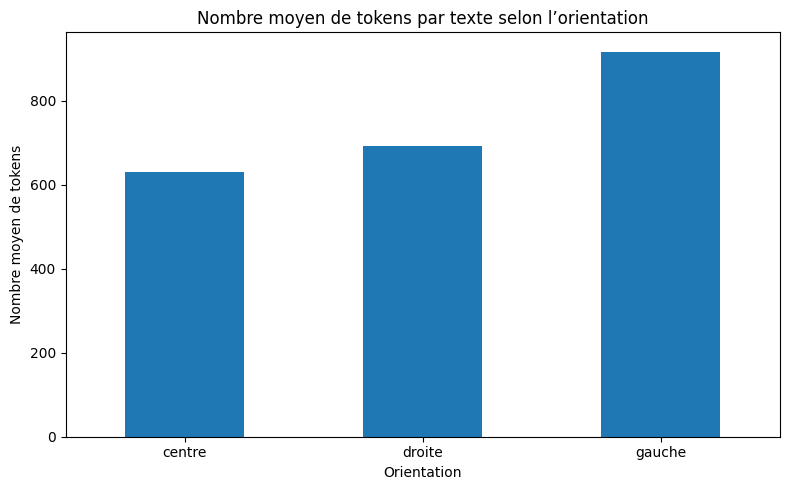


Longueur moyenne des textes par orientation :


,nb_tokens_moyen
orientation,
centre,629.63
droite,692.82
gauche,917.70


In [ ]:
# LONGUEUR MOYENNE PAR CLASSE (Nombre de tokens)

mean_words = df.groupby("orientation")["nb_tokens"].mean().sort_values()

plt.figure(figsize=(8, 5))
mean_words.plot(kind="bar")
plt.title("Nombre moyen de tokens par texte selon l’orientation")
plt.xlabel("Orientation")
plt.ylabel("Nombre moyen de tokens")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/moyenne_tokens_orientation.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nLongueur moyenne des textes par orientation :")
display(mean_words.round(2).to_frame(name="nb_tokens_moyen"))

In [ ]:
# STATISTIQUES PAR CLASSE

stats_par_classe = (
    df
    .groupby("orientation")[["nb_mots", "nb_phrases", "nb_tokens"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

print("\nStatistiques descriptives par orientation :")
display(stats_par_classe)


Statistiques descriptives par orientation :


nb_mots                                  nb_phrases                \
              count    mean median     std min   max      count   mean median   
orientation                                                                     
centre          999  537.95  466.0  296.33  78  2552        999  30.15   25.0   
droite         1601  595.89  506.0  334.25  43  2245       1601  32.08   26.0   
gauche         3601  783.36  705.0  370.11  49  3158       3601  42.29   37.0   

                            nb_tokens                                   
               std min  max     count    mean median     std min   max  
orientation                                                             
centre       19.07   1  232       999  629.63  546.0  350.21  82  3033  
droite       22.30   1  199      1601  692.82  592.0  392.02  44  2589  
gauche       23.17   1  166      3601  917.70  826.0  437.66  51  3622

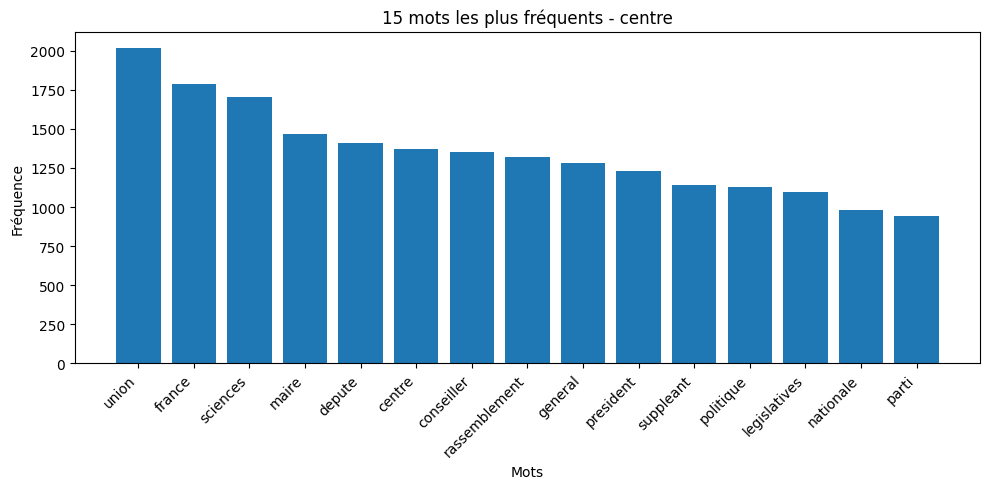

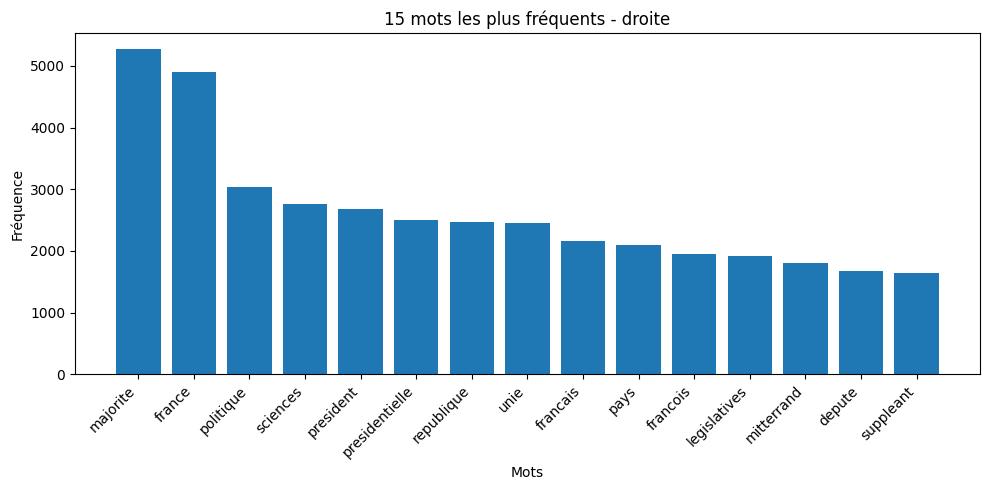

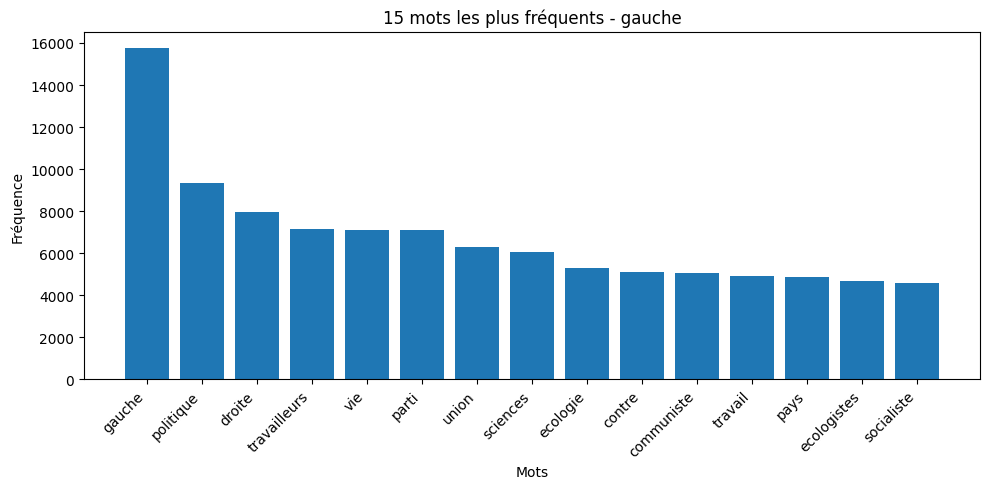

In [ ]:
# TOP MOTS PAR ORIENTATION


stopwords_fr = {
    "a", "à", "au", "aux", "avec", "ce", "ces", "dans", "de", "des", "du",
    "elle", "en", "et", "eux", "il", "je", "la", "le", "les", "leur", "lui",
    "ma", "mais", "me", "même", "mes", "moi", "mon", "ne", "nos", "notre",
    "nous", "on", "ou", "par", "pas", "pour", "qu", "que", "qui", "sa",
    "se", "ses", "son", "sur", "ta", "te", "tes", "toi", "ton", "tu", "un",
    "une", "vos", "votre", "vous", "c", "d", "l", "j", "n", "s", "y", "est",
    "sont", "été", "être", "avoir", "avait", "ont", "fait", "faire", "plus",
    "comme", "cela", "cette", "ces", "cet", "dans", "dont", "ainsi", "car",
    "si", "où", "leur", "leurs", "entre", "tous", "toutes", "tout", "candidat",
    "juin", "fonds", "cevipof", "etre", "ils", "ans", "candidats", "circonscription",
    "mars", "faut", "sans", "elections"
}

def normalize_text(text):
    text = str(text).lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def get_top_words(texts, n=15):
    all_words = []
    for text in texts:
        text = normalize_text(text)
        words = [w for w in text.split() if len(w) > 2 and w not in stopwords_fr]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

# Définition des classes
orientations = sorted(df["orientation"].dropna().unique())

for orientation in orientations:
    top_words = get_top_words(df.loc[df["orientation"] == orientation, "texte_clean"], n=15)
    
    mots = [w for w, c in top_words]
    freqs = [c for w, c in top_words]
    
    plt.figure(figsize=(10, 5))
    plt.bar(mots, freqs)
    plt.title(f"15 mots les plus fréquents - {orientation}")
    plt.xlabel("Mots")
    plt.ylabel("Fréquence")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"figures/top_mots_{orientation}.png", dpi=300, bbox_inches="tight")
    plt.show()